# Bodrum Hotel & Destination Intelligence
## 14 - Google Travel All-Hotels NLP & Aspect Analysis

Ana soru: "Müşteriler en çok neyi övüyor, neyi eleştiriyor?" 

In [1]:

import sys
sys.path.insert(0, r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews\src")
import re
import unicodedata
from collections import Counter
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import os

from bodrum_intelligence.analysis.aspect_dictionary import detect_aspects, ASPECT_KEYWORDS

REPO_ROOT = r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews"
FIG_DIR = REPO_ROOT + r"\reports\figures\google_travel_all_hotels_nlp"
os.makedirs(FIG_DIR, exist_ok=True)

clean = pd.read_csv(REPO_ROOT + r"\data\processed\google_travel_all_hotels_reviews_clean.csv")
tr = clean[clean["language_detected"] == "tr"].copy()
print("total rows:", len(clean), "| Turkish-detected rows used for NLP:", len(tr))


total rows: 2336 | Turkish-detected rows used for NLP: 2286


## D3-D4: Text normalization & brand stopwords

In [2]:

_TR_MAP = str.maketrans({"ı":"i","İ":"i","ş":"s","ğ":"g","ü":"u","ö":"o","ç":"c"})
BRAND_STOPWORDS = {"otel","hotel","resort","spa","bodrum","turkey","turkiye","bir","ve","bu","de","da",
                    "ile","icin","cok","gayet","genel","olarak","olan","gibi"}

def tokenize(text):
    if not isinstance(text, str) or not text:
        return []
    s = unicodedata.normalize("NFKD", text.lower().translate(_TR_MAP)).encode("ascii","ignore").decode("ascii")
    words = re.findall(r"[a-z]{3,}", s)
    return [w for w in words if w not in BRAND_STOPWORDS]

tr["tokens"] = tr["review_text_clean"].apply(tokenize)
tr["token_set"] = tr["tokens"].apply(set)
print("sample tokens:", tr["tokens"].iloc[0][:15] if len(tr) else [])


sample tokens: ['gece', 'kaldigimiz', 'aksoy', 'tasevden', 'memnun', 'ayrildik', 'otelle', 'denizin', 'arasinda', 'sadece', 'dar', 'yol', 'var', 'denizi', 'begendik']


## D5: Document frequency (top terms)

In [3]:

df_counter = Counter()
for toks in tr["token_set"]:
    df_counter.update(toks)
n_docs = max(len(tr), 1)
term_freq = pd.DataFrame(
    [{"term": t, "document_frequency": c, "document_frequency_pct": round(c/n_docs*100, 2)}
     for t, c in df_counter.most_common(40)]
)
term_freq.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_term_frequency.csv", index=False)
term_freq.head(20)


,term,document_frequency,document_frequency_pct
0,guzel,786,34.38
1,her,786,34.38
2,guler,610,26.68
3,tesekkur,599,26.20
4,otelin,546,23.88
5,daha,531,23.23
6,iyi,509,22.27
7,odalar,497,21.74
8,ama,495,21.65
9,gun,488,21.35


## D6: Bigrams

In [4]:

bigram_counter = Counter()
for toks in tr["tokens"]:
    for a, b in zip(toks, toks[1:]):
        bigram_counter[f"{a} {b}"] += 1
bigram_df = pd.DataFrame(
    [{"bigram": k, "count": v} for k, v in bigram_counter.most_common(30) if v >= 2]
)
bigram_df.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_bigram_frequency.csv", index=False)
bigram_df.head(15)


,bigram,count
0,guler yuzlu,448
1,tesekkur ederiz,332
2,memnun kaldik,298
3,her sey,246
4,tavsiye ederim,186
5,son derece,183
6,tesekkur ederim,158
7,her gun,155
8,denize sifir,125
9,gonul rahatligiyla,118


## D7-D8: LOW vs HIGH rating-group language

In [5]:

def top_terms_for(mask, n=15):
    c = Counter()
    for toks in tr.loc[mask, "token_set"]:
        c.update(toks)
    return c.most_common(n)

low_terms = top_terms_for(tr["rating_group"] == "LOW")
high_terms = top_terms_for(tr["rating_group"] == "HIGH")
distinctive = pd.DataFrame({
    "low_rating_top_terms": [t for t, _ in low_terms] + [""]*(15-len(low_terms)),
    "high_rating_top_terms": [t for t, _ in high_terms] + [""]*(15-len(high_terms)),
})
distinctive.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_rating_group_distinctive_terms.csv", index=False)
distinctive


,low_rating_top_terms,high_rating_top_terms
0,daha,her
1,ama,guzel
2,yok,tesekkur
3,gun,guler
4,kadar,memnun
5,var,ozellikle
6,otelin,temiz
7,otelde,otelin
8,oda,yuzlu
9,degil,odalar


## D12-D13: Aspect mention detection & hotel x aspect

In [6]:

tr["aspects"] = tr["review_text_clean"].apply(lambda t: detect_aspects(t) if isinstance(t, str) else set())

rows = []
for hotel_id, g in tr.groupby("hotel_id"):
    n = len(g)
    for aspect in ASPECT_KEYWORDS:
        mentioned = g["aspects"].apply(lambda s: aspect in s)
        cnt = int(mentioned.sum())
        if cnt == 0:
            continue
        rows.append({"hotel_id": hotel_id, "aspect": aspect, "mention_count": cnt,
                      "mention_rate_pct": round(cnt/n*100, 1), "support_n": n})
hotel_aspect = pd.DataFrame(rows)
hotel_aspect.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_hotel_aspect_mentions.csv", index=False)
print(len(hotel_aspect), "hotel x aspect rows with >=1 mention")
hotel_aspect.sort_values("mention_count", ascending=False).head(10)


1963 hotel x aspect rows with >=1 mention


,hotel_id,aspect,mention_count,mention_rate_pct,support_n
1414,BOD128,CLEANLINESS,56,64.4,87
1417,BOD128,ROOM,55,63.2,87
1413,BOD128,STAFF,54,62.1,87
617,BOD057,ROOM,54,68.4,79
656,BOD060,STAFF,54,70.1,77
1416,BOD128,FOOD,52,59.8,87
657,BOD060,CLEANLINESS,51,66.2,77
387,BOD032,STAFF,50,86.2,58
659,BOD060,FOOD,50,64.9,77
1419,BOD128,BEACH_SEA,50,57.5,87


## D14: Area x aspect

In [7]:

area_rows = []
for area, g in tr.groupby("area"):
    n = len(g)
    for aspect in ASPECT_KEYWORDS:
        mentioned = g["aspects"].apply(lambda s: aspect in s)
        cnt = int(mentioned.sum())
        if cnt == 0:
            continue
        area_rows.append({"area": area, "aspect": aspect, "mention_rate_pct": round(cnt/n*100, 1),
                           "support_n": n, "hotel_count": g["hotel_id"].nunique()})
area_aspect = pd.DataFrame(area_rows)
area_aspect.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_area_aspect_mentions.csv", index=False)
area_aspect.sort_values("mention_rate_pct", ascending=False).head(10)


,area,aspect,mention_rate_pct,support_n,hotel_count
261,Turgutreis,FOOD,76.7,30,2
51,Bodrum Merkez,FOOD,75.0,84,3
259,Turgutreis,CLEANLINESS,70.0,30,2
238,Torba,FOOD,69.5,187,11
48,Bodrum Merkez,STAFF,69.0,84,3
95,Gümbet,STAFF,67.3,364,11
98,Gümbet,FOOD,67.3,364,11
3,Akyarlar,FOOD,67.0,297,14
99,Gümbet,ROOM,66.2,364,11
4,Akyarlar,ROOM,66.0,297,14


## D15-D16: Aspect x rating (rating-context proxy, NOT sentiment)

In [8]:

aspect_rows = []
for aspect in ASPECT_KEYWORDS:
    mask = tr["aspects"].apply(lambda s: aspect in s)
    sub = tr[mask]
    if len(sub) == 0:
        continue
    aspect_rows.append({
        "aspect": aspect, "n_mentions": len(sub),
        "mean_rating_when_mentioned": round(sub["review_rating_numeric"].mean(), 2),
        "median_rating_when_mentioned": sub["review_rating_numeric"].median(),
        "low_rating_share_when_mentioned": round((sub["rating_group"]=="LOW").mean()*100, 1),
        "high_rating_share_when_mentioned": round((sub["rating_group"]=="HIGH").mean()*100, 1),
    })
aspect_rating = pd.DataFrame(aspect_rows).sort_values("n_mentions", ascending=False)
aspect_rating.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_aspect_rating_summary.csv", index=False)
aspect_rating


,aspect,n_mentions,mean_rating_when_mentioned,median_rating_when_mentioned,low_rating_share_when_mentioned,high_rating_share_when_mentioned
3,FOOD,1377,4.18,5.0,15.5,77.9
0,STAFF,1376,4.21,5.0,15.3,79.0
4,ROOM,1328,3.96,5.0,21.2,71.6
1,CLEANLINESS,1174,4.15,5.0,16.8,77.4
6,BEACH_SEA,1060,4.12,5.0,16.5,75.8
10,LOCATION,815,4.19,5.0,15.3,77.8
22,BAR_DRINKS,758,4.01,5.0,18.6,74.4
8,SERVICE,700,4.06,5.0,19.0,73.6
9,PRICE_VALUE,690,3.68,5.0,27.4,64.2
12,NOISE,594,3.85,5.0,23.4,68.7


## D17-D18: Hotel x aspect x rating-context (min support flagged)

In [9]:

hac_rows = []
for (hotel_id, aspect), g in tr.explode("aspects").dropna(subset=["aspects"]).groupby(["hotel_id","aspects"]):
    n = len(g)
    hac_rows.append({
        "hotel_id": hotel_id, "aspect": aspect, "mention_rate_n": n,
        "low_context_share": round((g["rating_group"]=="LOW").mean()*100,1),
        "high_context_share": round((g["rating_group"]=="HIGH").mean()*100,1),
        "mean_rating": round(g["review_rating_numeric"].mean(),2),
        "support_flag": "LOW_SUPPORT" if n < 3 else "OK",
    })
hotel_aspect_context = pd.DataFrame(hac_rows)
hotel_aspect_context.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_hotel_aspect_rating_context.csv", index=False)
hotel_aspect_context.sort_values("mention_rate_n", ascending=False).head(10)


,hotel_id,aspect,mention_rate_n,low_context_share,high_context_share,mean_rating,support_flag
1419,BOD128,CLEANLINESS,56,1.8,94.6,4.80,OK
1432,BOD128,ROOM,55,0.0,96.4,4.85,OK
676,BOD060,STAFF,54,9.3,88.9,4.50,OK
631,BOD057,ROOM,54,18.5,53.7,3.65,OK
1434,BOD128,STAFF,54,0.0,96.3,4.91,OK
1423,BOD128,FOOD,52,1.9,92.3,4.75,OK
661,BOD060,CLEANLINESS,51,15.7,82.4,4.24,OK
1416,BOD128,BEACH_SEA,50,2.0,96.0,4.80,OK
484,BOD045,FOOD,50,18.0,78.0,4.00,OK
407,BOD032,STAFF,50,2.0,92.0,4.62,OK


## D19: Heatmap - top hotels x top aspects (mention rate %)

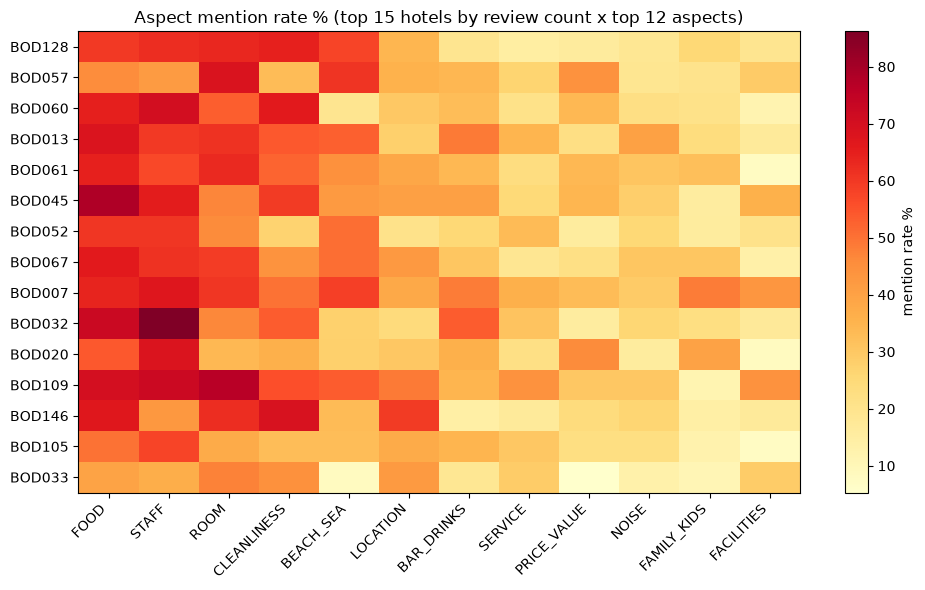

In [10]:

top_hotels = tr["hotel_id"].value_counts().head(15).index.tolist()
top_aspects = aspect_rating["aspect"].head(12).tolist()
pivot = hotel_aspect[hotel_aspect["hotel_id"].isin(top_hotels) & hotel_aspect["aspect"].isin(top_aspects)]
pivot_table = pivot.pivot(index="hotel_id", columns="aspect", values="mention_rate_pct").reindex(
    index=top_hotels, columns=top_aspects)

fig, ax = plt.subplots(figsize=(10, max(4, 0.4*len(top_hotels))))
im = ax.imshow(pivot_table.fillna(0).values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(top_aspects))); ax.set_xticklabels(top_aspects, rotation=45, ha="right")
ax.set_yticks(range(len(top_hotels))); ax.set_yticklabels(top_hotels)
ax.set_title("Aspect mention rate % (top 15 hotels by review count x top 12 aspects)")
plt.colorbar(im, ax=ax, label="mention rate %")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\hotel_aspect_heatmap.png", dpi=110)
plt.show()


### Grafik nasıl okunur?
Satırlar otel, sütunlar aspect (konu); renk koyulaştıkça o otelde o konudan bahsedilme oranı artar.
### Ne görüyoruz?
Hangi otellerde hangi konuların öne çıktığı tek bakışta karşılaştırılabilir.
### Neden önemli?
Otel bazlı güçlü/zayıf yön analizinin temelini oluşturur.
### Dikkat edilmesi gereken nokta
Yalnızca en çok yorum alan 15 otel gösterilmiştir; az örneklemli oteller için oranlar güvenilmezdir.

## D21-D22: Low-rating vs high-rating themes

In [11]:

low_aspect_rates = aspect_rating.sort_values("low_rating_share_when_mentioned", ascending=False).head(8)
high_aspect_rates = aspect_rating.sort_values("high_rating_share_when_mentioned", ascending=False).head(8)
print("Top LOW-context aspects:\n", low_aspect_rates[["aspect","low_rating_share_when_mentioned","n_mentions"]])
print("\nTop HIGH-context aspects:\n", high_aspect_rates[["aspect","high_rating_share_when_mentioned","n_mentions"]])


Top LOW-context aspects:
               aspect  low_rating_share_when_mentioned  n_mentions
18    REFUND_PAYMENT                             55.0         109
23              WIFI                             50.0          30
15  AIR_CONDITIONING                             44.6          65
17       RESERVATION                             43.9         221
21     COMMUNICATION                             43.1         116
2            HYGIENE                             42.7         185
16  CHECKIN_CHECKOUT                             29.3         283
9        PRICE_VALUE                             27.4         690

Top HIGH-context aspects:
                      aspect  high_rating_share_when_mentioned  n_mentions
19       TRANSPORT_TRANSFER                              81.0          21
14  ANIMATION_ENTERTAINMENT                              80.6         278
0                     STAFF                              79.0        1376
3                      FOOD                             

## D23: Customer voice profiles (sample-adequate hotels)

In [12]:

profiles = []
for hotel_id, g in tr.groupby("hotel_id"):
    n = len(g)
    if n < 5:
        continue
    ha = hotel_aspect[hotel_aspect["hotel_id"] == hotel_id].sort_values("mention_count", ascending=False)
    top_aspects_list = ha["aspect"].head(5).tolist()
    hac = hotel_aspect_context[hotel_aspect_context["hotel_id"] == hotel_id]
    strengths = hac[hac["high_context_share"] >= 60].sort_values("mention_rate_n", ascending=False)["aspect"].head(3).tolist()
    concerns = hac[hac["low_context_share"] >= 40].sort_values("mention_rate_n", ascending=False)["aspect"].head(3).tolist()
    profiles.append({
        "hotel_id": hotel_id, "hotel_name": g["hotel_name"].iloc[0], "area": g["area"].iloc[0],
        "review_n": n, "rating_profile": round(g["review_rating_numeric"].mean(), 2),
        "top_aspects": ";".join(top_aspects_list), "top_low_context_aspects": ";".join(concerns),
        "top_high_context_aspects": ";".join(strengths),
        "confidence_note": "MODERATE" if n < 20 else "STRONGER",
    })
voice_profiles = pd.DataFrame(profiles)
voice_profiles.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_customer_voice_profiles.csv", index=False)
print(len(voice_profiles), "hotels with n>=5 profiled")
voice_profiles.head(5)


104 hotels with n>=5 profiled


,hotel_id,hotel_name,area,review_n,rating_profile,top_aspects,top_low_context_aspects,top_high_context_aspects,confidence_note
0,BOD001,Aksoy Taş Ev,Akyarlar,28,5.00,BEACH_SEA;ROOM;FOOD;LOCATION;CLEANLINESS,,BEACH_SEA;ROOM;FOOD,STRONGER
1,BOD002,Armonia Holiday Village & Spa,Akyarlar,10,3.60,ROOM;FOOD;BAR_DRINKS;BED_COMFORT;STAFF,CLEANLINESS;NOISE;POOL,ROOM;FOOD;BAR_DRINKS,MODERATE
2,BOD003,ASPAT HOTEL BODRUM Beach Restaurant,Akyarlar,30,4.43,BEACH_SEA;STAFF;ROOM;CLEANLINESS;LOCATION,SERVICE;MANAGEMENT;REFUND_PAYMENT,BEACH_SEA;STAFF;ROOM,STRONGER
3,BOD004,Bendis Beach Hotel,Akyarlar,10,2.00,ROOM;CLEANLINESS;FAMILY_KIDS;STAFF;PRICE_VALUE,ROOM;CLEANLINESS;FAMILY_KIDS,ANIMATION_ENTERTAINMENT;REFUND_PAYMENT,MODERATE
4,BOD005,ByAkkan,Akyarlar,9,4.56,STAFF;FOOD;CLEANLINESS;ROOM;SERVICE,HYGIENE;MANAGEMENT;PRICE_VALUE,FOOD;STAFF;ROOM,MODERATE


## D25: Google-only NLP sensitivity

In [13]:

google_only_tr = tr[tr["review_source"] == "GOOGLE"]
sens = pd.DataFrame([{
    "all_sources_n": len(tr), "google_only_n": len(google_only_tr),
    "all_sources_top_term": term_freq.iloc[0]["term"] if len(term_freq) else None,
    "google_only_top_term": Counter(t for toks in google_only_tr["token_set"] for t in toks).most_common(1)[0][0]
        if len(google_only_tr) else None,
}])
sens.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_nlp_source_sensitivity.csv", index=False)
sens


,all_sources_n,google_only_n,all_sources_top_term,google_only_top_term
0,2286,2045,guzel,guzel


## D26: Topic modeling - SKIPPED
Corpus henüz çok küçük / hızla büyüyor; kararsız/aşırı-yorumlanabilir topic çıktısı riski var. Optional adım
olarak bilinçli şekilde atlandı (D26 kuralı: yalnız stabilse dahil et).

## D28: Notebook 14 - Key Findings

In [14]:

findings = []
findings.append(f"NLP corpus: {len(tr)} Turkish-detected reviews across {tr['hotel_id'].nunique()} hotels.")
if len(aspect_rating):
    findings.append("Top 10 aspects overall (by mention count): " + ", ".join(aspect_rating["aspect"].head(10).tolist()))
    findings.append("Top LOW-rating-context aspects: " + ", ".join(low_aspect_rates["aspect"].head(5).tolist()))
    findings.append("Top HIGH-rating-context aspects: " + ", ".join(high_aspect_rates["aspect"].head(5).tolist()))
findings.append(f"{len(voice_profiles)} hotels have n>=5 Turkish reviews and got a customer-voice profile; "
                 f"the rest need more data before aspect-level claims are reliable.")
findings.append("Rating-context shares are a proxy signal (co-occurrence with LOW/HIGH ratings), not a trained sentiment model.")
findings.append("Topic modeling (D26) was skipped - corpus not yet stable/large enough for interpretable topics.")
for i, f_ in enumerate(findings, 1):
    print(f"{i}. {f_}")


1. NLP corpus: 2286 Turkish-detected reviews across 104 hotels.
2. Top 10 aspects overall (by mention count): FOOD, STAFF, ROOM, CLEANLINESS, BEACH_SEA, LOCATION, BAR_DRINKS, SERVICE, PRICE_VALUE, NOISE
3. Top LOW-rating-context aspects: REFUND_PAYMENT, WIFI, AIR_CONDITIONING, RESERVATION, COMMUNICATION
4. Top HIGH-rating-context aspects: TRANSPORT_TRANSFER, ANIMATION_ENTERTAINMENT, STAFF, FOOD, LOCATION
5. 104 hotels have n>=5 Turkish reviews and got a customer-voice profile; the rest need more data before aspect-level claims are reliable.
6. Rating-context shares are a proxy signal (co-occurrence with LOW/HIGH ratings), not a trained sentiment model.
7. Topic modeling (D26) was skipped - corpus not yet stable/large enough for interpretable topics.
